# PitchGraph Line Drawing Test

This notebook ports the line-drawing logic from `src/components/PitchGraph.tsx` into Python.

- `extract_segments(contour)`: splits lines at unvoiced frames (`<= 0`)
- `plot_pitch_graph(...)`: draws user/reference pitch contours
- `assert` tests: verifies segment behavior

In [1]:
from typing import List, Tuple, Optional
import matplotlib.pyplot as plt

Point = Tuple[float, float]
Segment = List[Point]


In [2]:
def extract_segments(contour: List[float]) -> List[Segment]:
    """Mirror of drawLine() behavior in PitchGraph.tsx.

    - contour[i] <= 0 is unvoiced (pen up)
    - voiced points are connected until the next unvoiced frame
    """
    segments: List[Segment] = []
    current: Segment = []

    n = max(len(contour) - 1, 1)
    for i, f0 in enumerate(contour):
        if f0 <= 0:
            if len(current) >= 2:
                segments.append(current)
            current = []
            continue

        x = i / n
        current.append((x, f0))

    if len(current) >= 2:
        segments.append(current)

    return segments


In [3]:
def plot_pitch_graph(
    contour_user: List[float],
    contour_ref: Optional[List[float]] = None,
    divergent_regions: Optional[List[Tuple[int, int]]] = None,
    title: str = "Pitch Contour",
) -> None:
    contour_ref = contour_ref or []
    divergent_regions = divergent_regions or []

    all_voiced = [v for v in (contour_user + contour_ref) if v > 0]
    if not all_voiced:
        raise ValueError("No voiced frames in both user/ref contours")

    min_f = min(all_voiced) * 0.92
    max_f = max(all_voiced) * 1.08

    fig, ax = plt.subplots(figsize=(9, 3.6))
    ax.set_facecolor("#0f172a")
    fig.patch.set_facecolor("#0f172a")

    user_len = max(len(contour_user) - 1, 1)
    for s, e in divergent_regions:
        x1 = s / user_len
        x2 = e / user_len
        ax.axvspan(x1, x2, color="#ef4444", alpha=0.18)

    for seg in extract_segments(contour_ref):
        xs = [p[0] for p in seg]
        ys = [p[1] for p in seg]
        ax.plot(xs, ys, color="#fb923c", linestyle="--", linewidth=1.8, label="Reference")

    for seg in extract_segments(contour_user):
        xs = [p[0] for p in seg]
        ys = [p[1] for p in seg]
        ax.plot(xs, ys, color="#60a5fa", linewidth=2.4, label="User")

    handles, labels = ax.get_legend_handles_labels()
    if labels:
        uniq = dict(zip(labels, handles))
        ax.legend(uniq.values(), uniq.keys(), frameon=False, loc="lower left")

    ax.set_ylim(min_f, max_f)
    ax.set_xlim(0.0, 1.0)
    ax.grid(axis="y", color="white", alpha=0.08)
    ax.set_title(title)
    ax.set_ylabel("Hz")
    ax.set_xlabel("Normalized time")

    plt.tight_layout()
    plt.show()


In [4]:
# ---- Unit tests ----
assert extract_segments([0, 0, 0, -1, 0]) == []

seg = extract_segments([0, 110, 120, 130, 0])
assert len(seg) == 1
assert len(seg[0]) == 3

seg = extract_segments([100, 110, 0, 120, 130, 0, 140, 150])
assert len(seg) == 3
assert [len(s) for s in seg] == [2, 2, 2]

print("All tests passed")


All tests passed


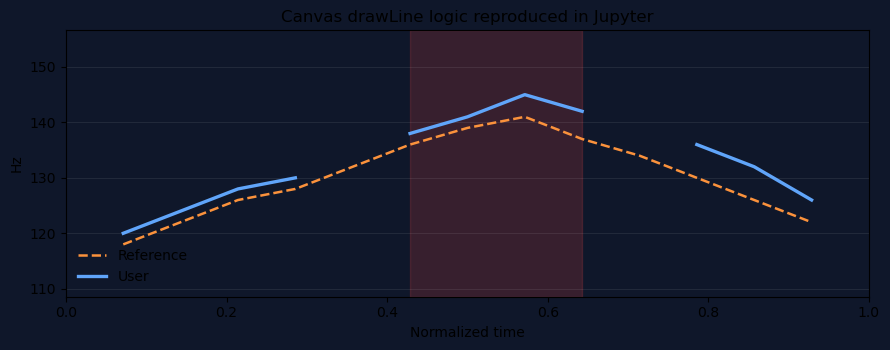

In [5]:
contour_user = [0, 120, 124, 128, 130, 0, 138, 141, 145, 142, 0, 136, 132, 126, 0]
contour_ref = [0, 118, 122, 126, 128, 132, 136, 139, 141, 137, 134, 130, 126, 122, 0]
divergent = [(6, 9)]

plot_pitch_graph(
    contour_user=contour_user,
    contour_ref=contour_ref,
    divergent_regions=divergent,
    title="Canvas drawLine logic reproduced in Jupyter",
)
